# 🎯 Master Multi-Asset Trainer (Quant Factory Edition)

Notebook ini adalah **Pabrik Model AI** profesional yang menggabungkan basis kuat dari `AI Trading Advanced V2` dengan sistem visualisasi *Quant-Level*.

### Fitur Unggulan:
1. **Zero-Data Assumption**: Secara otomatis mendownload data dari exchange jika file CSV belum tersedia atau tidak valid.
2. **High-Precision Metrics**: Menghapus format scientific (e-05) agar lu gampang baca loss & error.
3. **Advanced Quant Plot**: Visualisasi dual-subplot dengan *Shaded Error Area* dan *Gap Delta Bar*.
4. **Factory Logic**: Narik data otomatis, training otomatis, dan evaluasi dalam satu klik.
5. **Huber Architecture**: Lebih kebal terhadap 'fake pump/dump' dibanding model biasa.

In [ ]:
# === KONFIGURASI PABRIK ===
COIN = 'BTC'           # Pilihan: BTC, ETH, SOL
TIMEFRAME = '1h'      # Pilihan: 1h, 5
WINDOW_SIZE = 60      # Lookback 60 periode
FETCH_DATA = False    # Set True jika ingin FORCE download data baru meskipun file sudah ada

print(f"🏭 Factory Mode: Mempersiapkan Model {COIN} ({TIMEFRAME})")

🏭 Factory Mode: Mempersiapkan Model SOL (5)


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import ccxt
import joblib
import os
import time
from datetime import datetime
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, LSTM, Dense, Dropout, MultiHeadAttention, LayerNormalization, GlobalAveragePooling1D, Add
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
from ta.momentum import RSIIndicator
from ta.trend import MACD, SMAIndicator
from ta.volatility import BollingerBands, AverageTrueRange
from ta.volume import OnBalanceVolumeIndicator
import warnings

warnings.filterwarnings('ignore')
print(f"TensorFlow: {tf.__version__} | GPU: {tf.config.list_physical_devices('GPU')}")

I0000 00:00:1780313805.416140  555878 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780313805.592729  555878 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780313806.758493  555878 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
fatal: bad revision 'HEAD'


TensorFlow: 2.21.0 | GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Data Acquisition with Safety Validation

In [3]:
def fetch_historical_data(symbol, timeframe):
    exchange = ccxt.indodax()
    now = exchange.milliseconds()
    # 1H -> 5 Tahun, 5M -> 6 Bulan
    days = 365 * 5 if timeframe == '1h' else 30 * 6
    since = now - (days * 24 * 60 * 60 * 1000)
    
    all_ohlcv = []
    current_since = since
    print(f"📥 Memulai penarikan data {symbol} ({timeframe}) untuk {days} hari...")
    
    while current_since < now:
        try:
            ohlcv = exchange.fetch_ohlcv(symbol, timeframe, since=current_since, limit=1000)
            if not ohlcv: break
            
            all_ohlcv.extend(ohlcv)
            current_since = ohlcv[-1][0] + 1
            
            prog = min(100, ((current_since - since) / (now - since)) * 100)
            print(f"\r📊 Progres: {prog:.2f}% | Data: {len(all_ohlcv)}", end='')
            time.sleep(exchange.rateLimit / 1000)
            
            if (now - current_since) < (60 * 1000 * 60): break
        except: 
            time.sleep(2); continue
            
    df = pd.DataFrame(all_ohlcv, columns=['timestamp', 'open', 'high', 'low', 'close', 'volume'])
    return df

def ensure_data(coin, timeframe, force_fetch=False):
    fname = f"{coin.lower()}_idr_{timeframe}_data.csv"
    
    # Safety Check: Validasi jika file sudah ada dan layak pakai
    if not force_fetch and os.path.exists(fname):
        try:
            df = pd.read_csv(fname)
            required_cols = ['timestamp', 'open', 'high', 'low', 'close', 'volume']
            if all(col in df.columns for col in required_cols) and len(df) > 1000:
                print(f"✅ Data '{fname}' sudah tersedia secara lokal ({len(df)} baris). Skip penarikan.")
                return df
            else:
                print(f"⚠️ Data '{fname}' tidak valid. Menarik ulang...")
        except:
            print(f"⚠️ Gagal membaca '{fname}'. Menarik ulang...")

    # Tarik data dari Indodax
    df = fetch_historical_data(f"{coin}/IDR", timeframe)
    df.to_csv(fname, index=False)
    print(f"\n✅ Data {coin} berhasil disimpan ke {fname}")
    return df

# --- Eksekusi Penarikan Data ---
df_target = ensure_data(COIN, TIMEFRAME, force_fetch=FETCH_DATA)

if COIN != 'BTC':
    df_btc = ensure_data('BTC', TIMEFRAME, force_fetch=FETCH_DATA)
    df_btc = df_btc[['timestamp', 'close', 'volume']].rename(columns={'close': 'btc_close', 'volume': 'btc_volume'})
    df_target = pd.merge(df_target, df_btc, on='timestamp', how='inner')
    print("✅ Korelasi BTC digabungkan.")

📥 Memulai penarikan data SOL/IDR (5) untuk 180 hari...
📊 Progres: 100.00% | Data: 51840
✅ Data SOL berhasil disimpan ke sol_idr_5_data.csv
✅ Data 'btc_idr_5_data.csv' sudah tersedia secara lokal (51840 baris). Skip penarikan.
✅ Korelasi BTC digabungkan.


## 2. Feature Engineering & Multi-Variate Logic

In [4]:
def add_technical_indicators(df):
    df['vol_sma9'] = df['volume'].rolling(window=9).mean()
    df['rsi'] = RSIIndicator(close=df['close']).rsi()
    df['macd'] = MACD(close=df['close']).macd()
    df['atr'] = AverageTrueRange(high=df['high'], low=df['low'], close=df['close']).average_true_range()
    bb = BollingerBands(close=df['close'])
    df['bb_h'] = bb.bollinger_hband(); df['bb_l'] = bb.bollinger_lband()
    df['obv'] = OnBalanceVolumeIndicator(close=df['close'], volume=df['volume']).on_balance_volume()
    return df.dropna()

df_final = add_technical_indicators(df_target)
features = ['open', 'high', 'low', 'close', 'volume', 'vol_sma9', 'rsi', 'macd', 'atr', 'bb_h', 'bb_l', 'obv']
if 'btc_close' in df_final.columns: features += ['btc_close', 'btc_volume']
print(f"Total Fitur Input: {len(features)}")

Total Fitur Input: 14


## 3. Preprocessing (90/10 Split)

In [5]:
scaler_x = MinMaxScaler(); scaler_y = MinMaxScaler()
scaled_x = scaler_x.fit_transform(df_final[features])
scaled_y = scaler_y.fit_transform(df_final[['close']])

X, y = [], []
for i in range(len(scaled_x) - WINDOW_SIZE):
    X.append(scaled_x[i : i + WINDOW_SIZE])
    y.append(scaled_y[i + WINDOW_SIZE])

X, y = np.array(X), np.array(y)
split = int(len(X) * 0.9)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

## 4. Arsitektur Model Sniper (V2 Base)

In [6]:
def build_model(input_shape):
    inputs = Input(shape=input_shape)
    x = Conv1D(64, 3, activation='relu', padding='same')(inputs)
    x = MaxPooling1D(2)(x)
    x = Conv1D(128, 3, activation='relu', padding='same')(x)
    x = LSTM(128, return_sequences=True)(x)
    x = Dropout(0.2)(x)
    x = LSTM(64, return_sequences=True)(x)
    att = MultiHeadAttention(num_heads=4, key_dim=64)(x, x)
    x = LayerNormalization()(Add()([x, att]))
    x = GlobalAveragePooling1D()(x)
    x = Dense(32, activation='relu')(x)
    out = Dense(1)(x)
    model = Model(inputs, out)
    model.compile(optimizer='adam', loss=tf.keras.losses.Huber(), metrics=['mae'])
    return model

model = build_model((WINDOW_SIZE, len(features)))
model.summary()

I0000 00:00:1780313937.123681  555878 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4179 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 6GB Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 60, 14)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 60, 64)    │      2,752 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 30, 64)    │          0 │ conv1d[0][0]      │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 30, 128)   │     24,704 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 30, 128)   │    131,584 │ conv1d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 30, 128)   │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 30, 64)    │     49,408 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 30, 64)    │     66,368 │ lstm_1[0][0],     │
│ (MultiHeadAttentio… │                   │            │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 30, 64)    │          0 │ lstm_1[0][0],     │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 30, 64)    │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │      2,080 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         33 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 277,057 (1.06 MB)

 Trainable params: 277,057 (1.06 MB)

 Non-trainable params: 0 (0.00 B)

## 5. Training dengan Readable Metrics

In [7]:
class ReadableProgress(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        l = logs.get('loss'); vl = logs.get('val_loss'); m = logs.get('mae')
        print(f"\rEpoch {epoch+1:03d} | Loss: {l:.7f} | Val Loss: {vl:.7f} | MAE: {m:.5f}", end="")

callbacks = [
    EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6),
    ReadableProgress()
]
print("Training Factory Started...")
model.fit(X_train, y_train, validation_split=0.1, epochs=60, batch_size=64, callbacks=callbacks, verbose=0)
print("\n✅ Training Selesai!")

Training Factory Started...


I0000 00:00:1780313939.992247  557271 cuda_dnn.cc:461] Loaded cuDNN version 92300


Epoch 041 | Loss: 0.0000107 | Val Loss: 0.0000119 | MAE: 0.00331
✅ Training Selesai!


## 6. 🔥 Quant-Level Evaluation Tool

162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

--- FINAL ACCURACY --- 
MAPE Accuracy: 0.25% | Directional: 34.89% | MAE: Rp 3,785


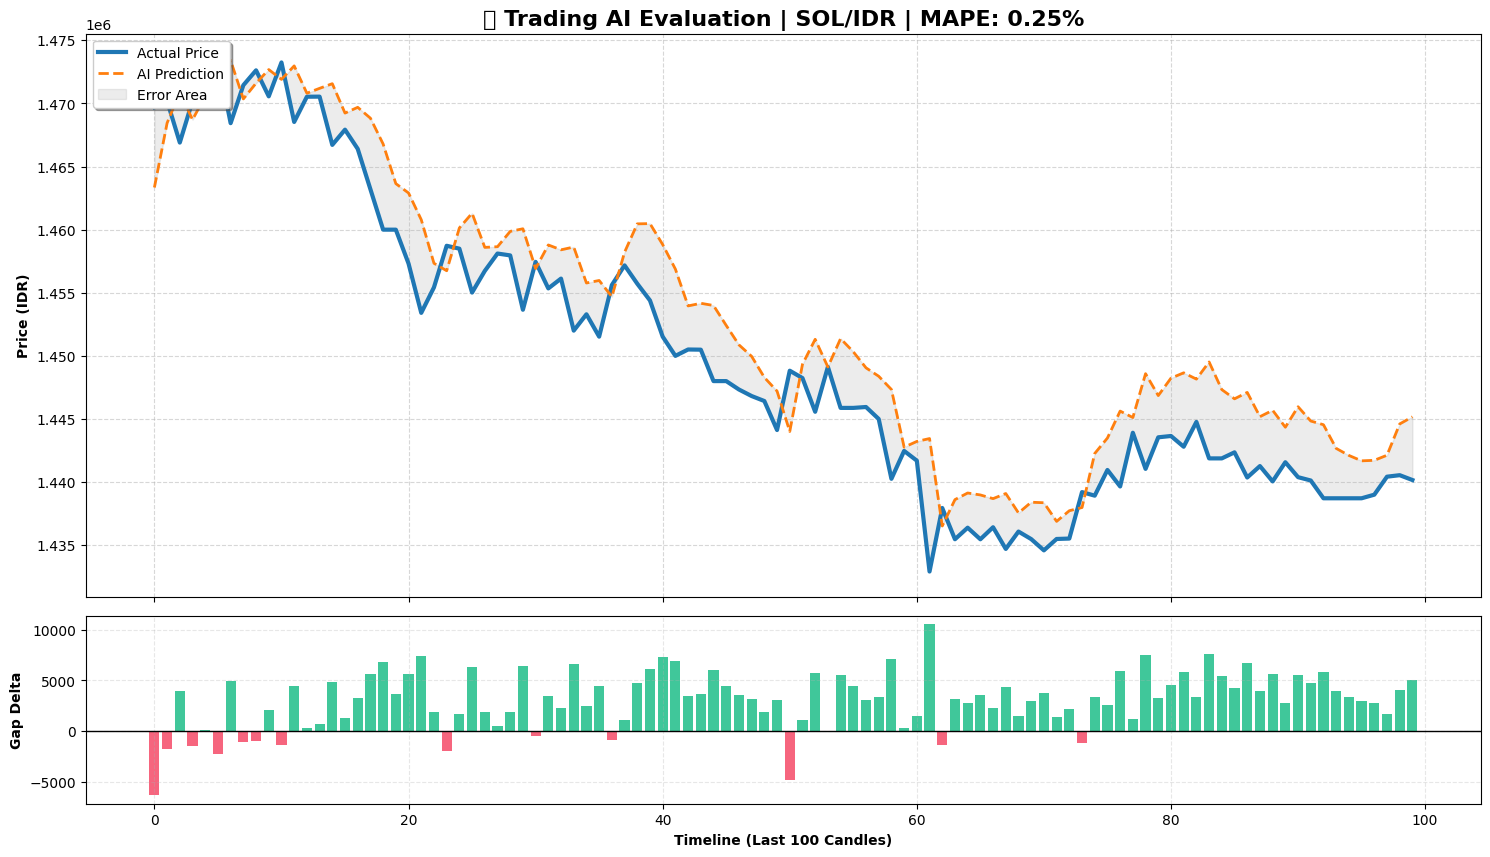


--- TABEL PERBANDINGAN 10 DATA TERAKHIR ---


,Real,AI,Gap,Error %
90,"1,440,388","1,445,968","+5,580",0.39%
91,"1,440,124","1,444,838","+4,714",0.33%
92,"1,438,715","1,444,544","+5,828",0.41%
93,"1,438,715","1,442,669","+3,954",0.27%
94,"1,438,715","1,442,111","+3,396",0.24%
95,"1,438,715","1,441,682","+2,967",0.21%
96,"1,439,000","1,441,724","+2,724",0.19%
97,"1,440,426","1,442,126","+1,700",0.12%
98,"1,440,546","1,444,606","+4,060",0.28%
99,"1,440,161","1,445,170","+5,009",0.35%


In [8]:
#  Prediksi pada data test
y_p_scaled = model.predict(X_test)

# GUNAKAN scaler_y (Sesuai nama variabel di sel Preprocessing)
y_p = scaler_y.inverse_transform(y_p_scaled)
y_t = scaler_y.inverse_transform(y_test)

# 2. Hitung Metrik
mape = np.mean(np.abs((y_t - y_p) / y_t)) * 100
mae = mean_absolute_error(y_t, y_p)

# Akurasi Arah (Directional Accuracy)
true_diff = np.diff(y_t.flatten())
pred_diff = np.diff(y_p.flatten())
da = np.mean(np.sign(true_diff) == np.sign(pred_diff)) * 100

print(f"\n--- FINAL ACCURACY --- ")
print(f"MAPE Accuracy: {mape:.2f}% | Directional: {da:.2f}% | MAE: Rp {mae:,.0f}")

# 3. Advanced Quant Plot (Last 100 Candles)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 10), height_ratios=[3, 1], sharex=True)
plt.subplots_adjust(hspace=0.05)

indices = np.arange(100)
real = y_t[-100:].flatten()
pred = y_p[-100:].flatten()
gaps = pred - real

# Subplot 1: Price & Shaded Error Area
ax1.plot(indices, real, label='Actual Price', color='#1f77b4', linewidth=3)
ax1.plot(indices, pred, label='AI Prediction', color='#ff7f0e', linestyle='--', linewidth=2)
ax1.fill_between(indices, real, pred, color='gray', alpha=0.15, label='Error Area')
ax1.set_title(f"📊 Trading AI Evaluation | {COIN}/IDR | MAPE: {mape:.2f}%", fontsize=16, fontweight='bold')
ax1.set_ylabel("Price (IDR)", fontweight='bold')
ax1.legend(loc='upper left', shadow=True)
ax1.grid(True, linestyle='--', alpha=0.5)

# Subplot 2: Gap Delta Bar (Hijau = Tebakan di atas Market, Merah = Di bawah)
colors = ['#10b981' if g >= 0 else '#f43f5e' for g in gaps]
ax2.bar(indices, gaps, color=colors, alpha=0.8, label='Gap (Predict - Actual)')
ax2.axhline(0, color='black', linewidth=1)
ax2.set_ylabel("Gap Delta", fontweight='bold')
ax2.set_xlabel("Timeline (Last 100 Candles)", fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.3)
plt.show()

# 4. Tabel Perbandingan 10 Data Terakhir
gap_df = pd.DataFrame({'Real': real, 'AI': pred, 'Gap': gaps})
gap_df['Error %'] = (np.abs(gaps) / real) * 100
print("\n--- TABEL PERBANDINGAN 10 DATA TERAKHIR ---")
display(gap_df.tail(10).style.format({
    'Real': '{:,.0f}', 
    'AI': '{:,.0f}', 
    'Gap': '{:+,.0f}', 
    'Error %': '{:.2f}%'
}))

## 7. Save Models

In [9]:
os.makedirs('models', exist_ok=True)

# Standarisasi Suffix: 1h -> 1h, 5m -> 5 (Sesuai ModelManager)
TF_SUFFIX = '1h' if TIMEFRAME == '1h' else '5'
m_name = f"models/{COIN.upper()}_{TF_SUFFIX}.keras"
s_x_name = f"models/{COIN.upper()}_{TF_SUFFIX}_scaler_x.pkl"
s_y_name = f"models/{COIN.upper()}_{TF_SUFFIX}_scaler_y.pkl"

model.save(m_name)
joblib.dump(scaler_x, s_x_name)
joblib.dump(scaler_y, s_y_name)
print(f"✅ Berhasil simpan: {m_name}")

✅ Saved models/SOL_5.keras
